In [14]:
!wget --no-cache -O init.py -q https://raw.githubusercontent.com/UDEA-Esp-Analitica-y-Ciencia-de-Datos/EACD-08-CLOUD/master/init.py
import init; init.init(force_download=False);
from IPython.display import Image

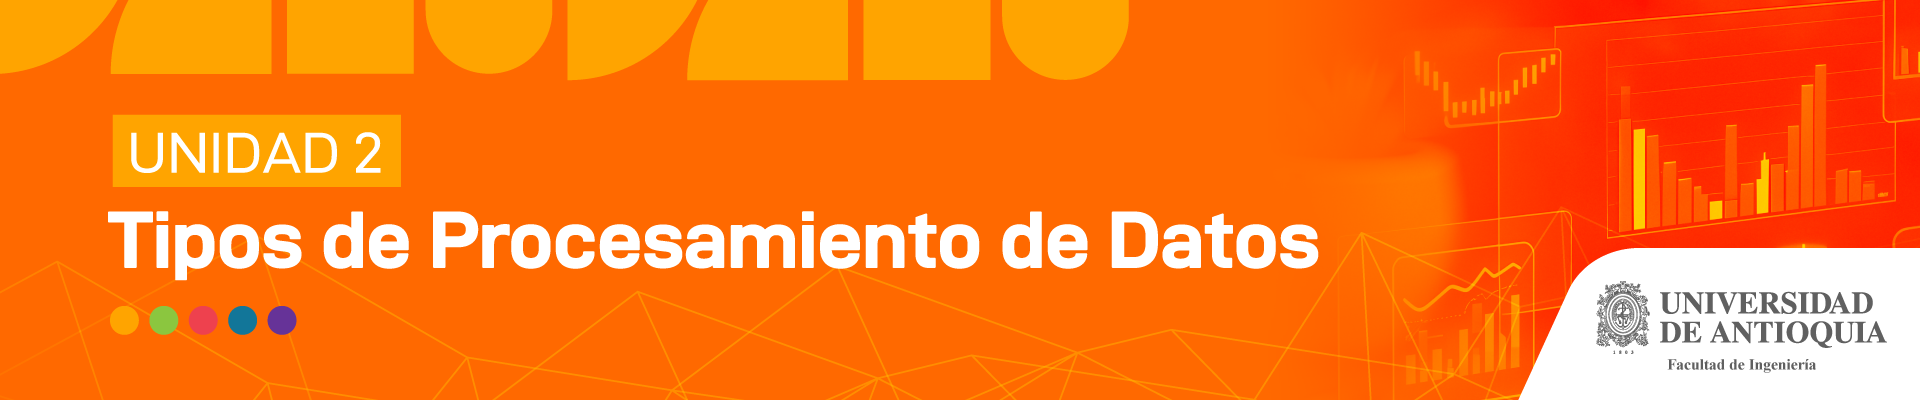

In [15]:
Image("local/imgs/unidad-2.png")


# Batch Processing
## Simulación de *ventas diarias* y generación de reporte **batch**

Vamos a comprender de forma práctica, cómo funciona el **Batch Processing** usando un escenario cotidiano:

> **Una tienda registra ventas durante el día** y al final genera un **reporte consolidado** (batch).

### ¿Qué aprenderás aquí?
- Qué significa **acumular datos** antes de procesarlos.
- Por qué el batch tiene **latencia alta** y por qué, en muchos casos, eso es **aceptable**.
- Cómo un proceso batch produce **resultados agregados** (totales, promedios, top productos) en vez de reaccionar evento a evento.


## 1. Conceptos básicos antes de empezar
Antes de ver código, aclaremos algunas ideas que usaremos en este notebook.
### 🧱 ¿Qué es Batch Processing?
Batch Processing es un paradigma donde:
1. **Los datos se generan y almacenan** durante un período (por ejemplo, un día).
2. Luego, en un momento específico (por ejemplo, a las 11:59 pm), se ejecuta un **proceso batch**.
3. El proceso batch produce resultados **consolidados**: totales, promedios, rankings, tablas resumen.

### ⏳ ¿Por qué la latencia es aceptable?
Porque en escenarios como:
- Reportes diarios de ventas
- Facturación
- Nómina
- Análisis histórico

no necesitamos actuar en milisegundos. Lo importante es:
- **Exactitud**
- **Consistencia**
- **Completitud**

### 🎯 ¿Cuál es el “producto” típico de un batch?
Un **reporte** (o tablas agregadas) que responde a preguntas como:
- ¿Cuánto vendimos hoy?
- ¿Cuál fue el producto más vendido?
- ¿En qué hora vendimos más?
- ¿Cuál fue el ticket promedio?

---

En este notebook simularemos un día de ventas (acelerado) y luego generaremos ese reporte.



## 2. Preparar el entorno

Usaremos:
- `pandas` para manipular datos tabulares.
- `matplotlib` para gráficos.
- `datetime` para estampas de tiempo

In [16]:
import random
import math
from datetime import datetime, timedelta, timezone

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrow



## 3. Escenario: Tienda con catálogo de productos
Vamos a simular una tienda con un catálogo sencillo. Cada venta tendrá:

- Fecha/hora
- Producto
- Cantidad
- Precio unitario
- Total de la venta

En Batch Processing, el flujo típico es:

1. **Se registran ventas** durante el día (se guardan en almacenamiento).
2. **No se procesan** una por una para producir métricas en tiempo real.
3. Al final del día se ejecuta un **proceso batch** que genera el reporte.


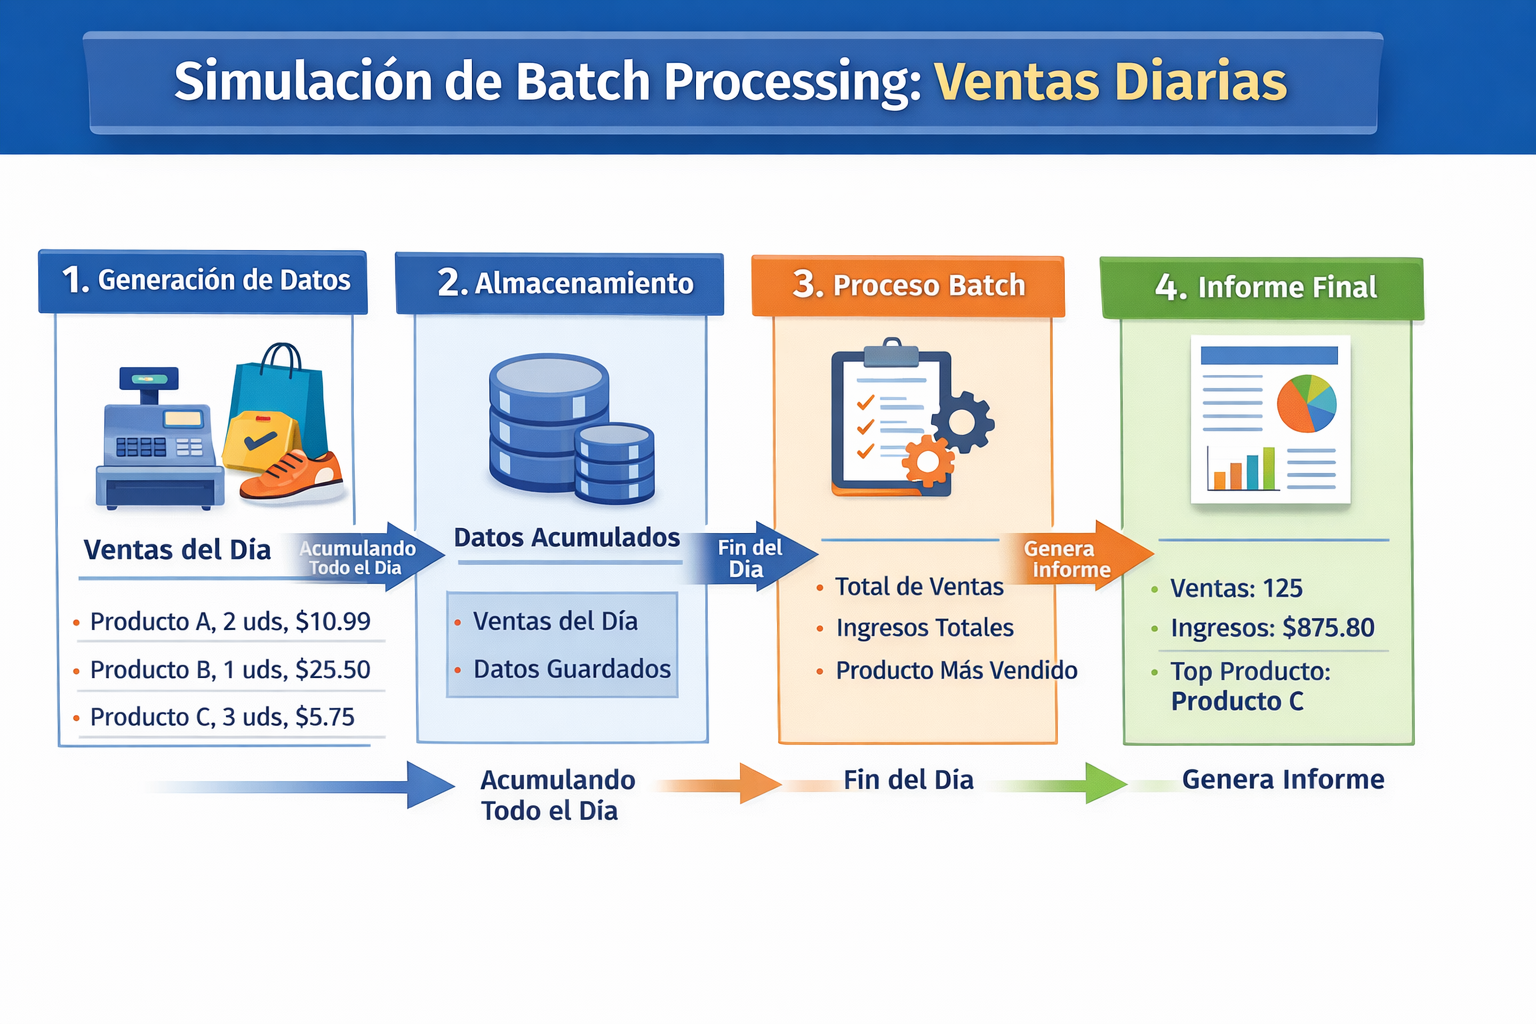

In [17]:
Image("local/imgs/tienda.png")

In [18]:
CATALOGO = [
    {"producto_id": "P001", "nombre": "Café",     "precio": 2.5},
    {"producto_id": "P002", "nombre": "Pan",      "precio": 1.2},
    {"producto_id": "P003", "nombre": "Leche",    "precio": 1.8},
    {"producto_id": "P004", "nombre": "Huevos",   "precio": 3.9},
    {"producto_id": "P005", "nombre": "Arroz",    "precio": 2.1},
    {"producto_id": "P006", "nombre": "Queso",    "precio": 4.5},
    {"producto_id": "P007", "nombre": "Galletas", "precio": 1.6},
    {"producto_id": "P008", "nombre": "Jugo",     "precio": 2.9},
]

df_catalogo = pd.DataFrame(CATALOGO)
df_catalogo

,producto_id,nombre,precio
0,P001,Café,2.5
1,P002,Pan,1.2
2,P003,Leche,1.8
3,P004,Huevos,3.9
4,P005,Arroz,2.1
5,P006,Queso,4.5
6,P007,Galletas,1.6
7,P008,Jugo,2.9



## 4. Simular ventas durante un día (datos que se acumulan)

Generaremos ventas con timestamps a lo largo del día y con “horas pico” (mayor cantidad de ventas en ciertos horarios).

**Importante:** en este punto solo *generamos y almacenamos* los datos.  
Aún no generamos reportes (eso vendrá al final).


In [19]:
def utc_iso(dt: datetime) -> str:
    """Devuelve un timestamp ISO 8601 en UTC, terminado en Z."""
    return dt.astimezone(timezone.utc).isoformat().replace("+00:00", "Z")

def peso_hora(h: int) -> float:
    """Función simple para simular horas pico (más ventas en ciertas horas)."""
    pico_1 = math.exp(-((h - 9) ** 2) / (2 * 1.5 ** 2))   # ~9am
    pico_2 = math.exp(-((h - 18) ** 2) / (2 * 1.8 ** 2))  # ~6pm
    base = 0.15
    return base + pico_1 + pico_2

def simular_ventas_diarias(
    fecha_local: datetime,
    num_ventas: int = 1200,
    tz=timezone.utc,
    seed: int = 42
) -> pd.DataFrame:
    """Simula ventas de un solo día con mayor probabilidad en horas pico."""
    random.seed(seed)

    inicio_dia = datetime(fecha_local.year, fecha_local.month, fecha_local.day, 0, 0, 0, tzinfo=tz)

    # distribución por hora
    pesos = [peso_hora(h) for h in range(24)]
    suma = sum(pesos)
    probs = [p / suma for p in pesos]

    ventas = []
    for venta_id in range(1, num_ventas + 1):
        hora = random.choices(range(24), weights=probs, k=1)[0]
        minuto = random.randint(0, 59)
        segundo = random.randint(0, 59)
        ts = datetime(inicio_dia.year, inicio_dia.month, inicio_dia.day, hora, minuto, segundo, tzinfo=tz)

        item = random.choice(CATALOGO)
        cantidad = random.choices([1, 2, 3, 4, 5], weights=[55, 25, 12, 6, 2], k=1)[0]
        precio = float(item["precio"])
        total = round(cantidad * precio, 2)

        ventas.append({
            "venta_id": venta_id,
            "timestamp": ts,
            "timestamp_iso": utc_iso(ts),
            "producto_id": item["producto_id"],
            "producto": item["nombre"],
            "cantidad": cantidad,
            "precio_unitario": precio,
            "total": total,
        })

    df = pd.DataFrame(ventas).sort_values("timestamp").reset_index(drop=True)
    return df

df_ventas = simular_ventas_diarias(datetime.now(timezone.utc), num_ventas=1200, tz=timezone.utc, seed=42)
df_ventas.head(10)

,venta_id,timestamp,timestamp_iso,producto_id,producto,cantidad,precio_unitario,total
0,413,2026-04-18 00:06:27+00:00,2026-04-18T00:06:27Z,P003,Leche,3,1.8,5.4
1,552,2026-04-18 00:26:24+00:00,2026-04-18T00:26:24Z,P002,Pan,2,1.2,2.4
2,454,2026-04-18 00:36:38+00:00,2026-04-18T00:36:38Z,P002,Pan,4,1.2,4.8
3,934,2026-04-18 00:38:25+00:00,2026-04-18T00:38:25Z,P002,Pan,1,1.2,1.2
4,795,2026-04-18 00:42:53+00:00,2026-04-18T00:42:53Z,P006,Queso,2,4.5,9.0
5,1035,2026-04-18 00:43:13+00:00,2026-04-18T00:43:13Z,P007,Galletas,2,1.6,3.2
6,822,2026-04-18 00:46:15+00:00,2026-04-18T00:46:15Z,P004,Huevos,2,3.9,7.8
7,879,2026-04-18 00:47:03+00:00,2026-04-18T00:47:03Z,P007,Galletas,3,1.6,4.8
8,108,2026-04-18 00:48:55+00:00,2026-04-18T00:48:55Z,P002,Pan,2,1.2,2.4
9,933,2026-04-18 00:55:35+00:00,2026-04-18T00:55:35Z,P003,Leche,1,1.8,1.8



### 4.1 “Almacenamiento” de las ventas (persistencia)

En un sistema real, estas ventas se guardarían en una base de datos o en un data lake.  
Aquí las guardaremos como un CSV para simular persistencia.


In [20]:
ruta_csv = "local/data/ventas_diarias.csv"
df_ventas.to_csv(ruta_csv, index=False)
ruta_csv

'local/data/ventas_diarias.csv'


✅ Hasta aquí, lo único que hicimos fue:
- Generar ventas
- Almacenarlas (CSV).

**Todavía no hicimos ninguna métrica final.**  
Eso es intencional: en batch, el procesamiento ocurre al final.



## 5. Paso “batch”: generar el reporte diario

Ahora simularemos el momento del batch:

> “Terminó el día. Ejecutemos el job batch del reporte diario.”

El job leerá el CSV y construirá resultados agregados como:
- Ventas totales
- Ingresos totales
- Ticket promedio
- Top productos
- Ventas por hora


In [21]:
def job_batch_reporte_diario(ruta_csv: str) -> dict:
    df = pd.read_csv(ruta_csv, parse_dates=["timestamp"])
    df["hora"] = df["timestamp"].dt.hour

    ventas_totales = int(df["venta_id"].nunique())
    ingresos_totales = float(df["total"].sum())
    unidades_totales = int(df["cantidad"].sum())
    ticket_promedio = float(df["total"].mean())

    top_ingresos = (
        df.groupby(["producto_id", "producto"], as_index=False)["total"]
        .sum()
        .sort_values("total", ascending=False)
        .head(5)
        .reset_index(drop=True)
    )

    top_unidades = (
        df.groupby(["producto_id", "producto"], as_index=False)["cantidad"]
        .sum()
        .sort_values("cantidad", ascending=False)
        .head(5)
        .reset_index(drop=True)
    )

    ventas_por_hora = (
        df.groupby("hora", as_index=False)
        .agg(ventas=("venta_id", "count"), ingresos=("total", "sum"), unidades=("cantidad", "sum"))
        .sort_values("hora")
        .reset_index(drop=True)
    )

    return {
        "df": df,
        "ventas_totales": ventas_totales,
        "ingresos_totales": ingresos_totales,
        "unidades_totales": unidades_totales,
        "ticket_promedio": ticket_promedio,
        "top_ingresos": top_ingresos,
        "top_unidades": top_unidades,
        "ventas_por_hora": ventas_por_hora,
    }

reporte = job_batch_reporte_diario(ruta_csv)
reporte["ventas_totales"], reporte["ingresos_totales"], reporte["unidades_totales"], reporte["ticket_promedio"]

(1200, 5355.799999999999, 2095, 4.463166666666666)


### 5.1 Resultados principales del reporte batch

Este es el tipo de salida que esperarías en un reporte diario.  
Observa que todo esto se calcula **después** de que el día terminó.


In [22]:
print("=== REPORTE BATCH DIARIO ===")
print(f"Ventas totales:   {reporte['ventas_totales']}")
print(f"Ingresos totales: {reporte['ingresos_totales']:.2f}")
print(f"Unidades totales: {reporte['unidades_totales']}")
print(f"Ticket promedio:  {reporte['ticket_promedio']:.2f}")

=== REPORTE BATCH DIARIO ===
Ventas totales:   1200
Ingresos totales: 5355.80
Unidades totales: 2095
Ticket promedio:  4.46



### 5.2 Top productos (por ingresos)


In [23]:
reporte["top_ingresos"]

,producto_id,producto,total
0,P006,Queso,1161.0
1,P004,Huevos,920.4
2,P008,Jugo,788.8
3,P001,Café,757.5
4,P005,Arroz,581.7



### 5.3 Top productos (por unidades)


In [24]:
reporte["top_unidades"]

,producto_id,producto,cantidad
0,P001,Café,303
1,P005,Arroz,277
2,P008,Jugo,272
3,P006,Queso,258
4,P002,Pan,254



## 6. Visualizaciones típicas de un reporte batch


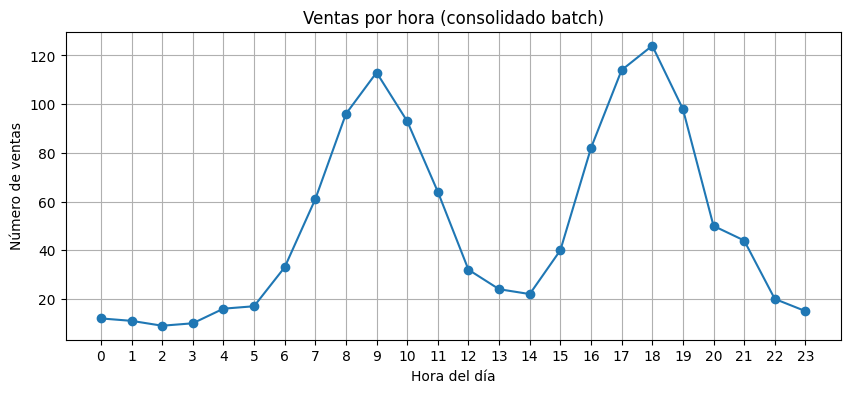

In [25]:
ventas_por_hora = reporte["ventas_por_hora"]

plt.figure(figsize=(10, 4))
plt.plot(ventas_por_hora["hora"], ventas_por_hora["ventas"], marker="o")
plt.title("Ventas por hora (consolidado batch)")
plt.xlabel("Hora del día")
plt.ylabel("Número de ventas")
plt.xticks(range(0, 24, 1))
plt.grid(True)
plt.show()

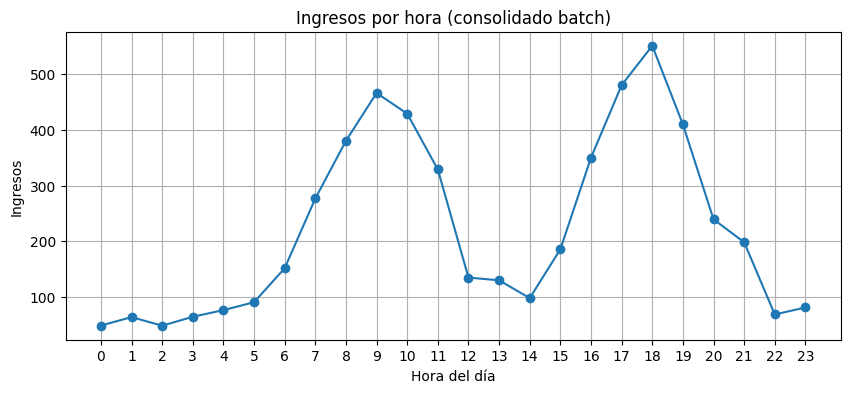

In [26]:
plt.figure(figsize=(10, 4))
plt.plot(ventas_por_hora["hora"], ventas_por_hora["ingresos"], marker="o")
plt.title("Ingresos por hora (consolidado batch)")
plt.xlabel("Hora del día")
plt.ylabel("Ingresos")
plt.xticks(range(0, 24, 1))
plt.grid(True)
plt.show()


## 7. ¿Dónde aparece la “latencia” en batch?

En batch, una venta que ocurre a las 9:15 am puede verse reflejada en el reporte final muchas horas después.

Esto es aceptable cuando:
- el objetivo es consolidar el día,
- el negocio toma decisiones con reportes diarios,
- se prioriza consistencia y costo.

No sería aceptable en casos como fraude o alertas críticas (eso es streaming).



## 8. Ejercicios propuestos

1. Cambia `num_ventas` a 5000 o 20000.  
2. Agrega una columna `descuento` y calcula ingresos netos.  
3. Segmenta ingresos por franjas horarias (mañana/tarde/noche).  
4. Calcula top productos por franja horaria.  
5. Introduce datos erróneos (cantidad 0, precio negativo) y crea una etapa de limpieza antes del reporte.


## 8.1 Ejercicio 1 — Cambiar `num_ventas`

Reutilizamos la función `simular_ventas_diarias` y el `job_batch_reporte_diario`
para ver cómo varían las métricas con 5.000 y 20.000 ventas.


In [33]:
escenarios = [5000, 20000]
resumen_escenarios = []

for n in escenarios:
    df_n = simular_ventas_diarias(
        datetime.now(timezone.utc), num_ventas=n, tz=timezone.utc, seed=42
    )
    ruta_n = f"local/data/ventas_diarias_{n}.csv"
    df_n.to_csv(ruta_n, index=False)
    rep_n = job_batch_reporte_diario(ruta_n)
    resumen_escenarios.append({
        "num_ventas": n,
        "ventas_totales": rep_n["ventas_totales"],
        "ingresos_totales": round(rep_n["ingresos_totales"], 2),
        "unidades_totales": rep_n["unidades_totales"],
        "ticket_promedio": round(rep_n["ticket_promedio"], 2),
    })

df_resumen = pd.DataFrame(resumen_escenarios)
df_resumen

,num_ventas,ventas_totales,ingresos_totales,unidades_totales,ticket_promedio
0,5000,5000,22378.2,8732,4.48
1,20000,20000,89519.5,34895,4.48


## 8.2 Ejercicio 2 — Columna `descuento` e ingresos netos

Añadimos un descuento aleatorio por venta (entre 0% y 20%) y calculamos el
ingreso **neto** = `total * (1 - descuento)`. El reporte batch también
reporta ingresos brutos, descuentos aplicados e ingresos netos.


In [34]:
def aplicar_descuentos(df: pd.DataFrame, seed: int = 7) -> pd.DataFrame:
    rng = random.Random(seed)
    df = df.copy()
    df["descuento"] = [round(rng.uniform(0.0, 0.20), 2) for _ in range(len(df))]
    df["total_neto"] = (df["total"] * (1 - df["descuento"])).round(2)
    df["monto_descuento"] = (df["total"] - df["total_neto"]).round(2)
    return df


df_ventas_desc = aplicar_descuentos(df_ventas)
ruta_desc = "local/data/ventas_con_descuento.csv"
df_ventas_desc.to_csv(ruta_desc, index=False)

ingreso_bruto = df_ventas_desc["total"].sum()
descuento_total = df_ventas_desc["monto_descuento"].sum()
ingreso_neto = df_ventas_desc["total_neto"].sum()

print(f"Ingreso bruto:      {ingreso_bruto:.2f}")
print(f"Descuentos:         {descuento_total:.2f}")
print(f"Ingreso neto:       {ingreso_neto:.2f}")
print(f"Descuento promedio: {df_ventas_desc['descuento'].mean()*100:.2f}%")

df_ventas_desc.head()

Ingreso bruto:      5355.80
Descuentos:         519.33
Ingreso neto:       4836.47
Descuento promedio: 9.70%


,venta_id,timestamp,timestamp_iso,producto_id,producto,cantidad,precio_unitario,total,descuento,total_neto,monto_descuento
0,413,2026-04-18 00:06:27+00:00,2026-04-18T00:06:27Z,P003,Leche,3,1.8,5.4,0.06,5.08,0.32
1,552,2026-04-18 00:26:24+00:00,2026-04-18T00:26:24Z,P002,Pan,2,1.2,2.4,0.03,2.33,0.07
2,454,2026-04-18 00:36:38+00:00,2026-04-18T00:36:38Z,P002,Pan,4,1.2,4.8,0.13,4.18,0.62
3,934,2026-04-18 00:38:25+00:00,2026-04-18T00:38:25Z,P002,Pan,1,1.2,1.2,0.01,1.19,0.01
4,795,2026-04-18 00:42:53+00:00,2026-04-18T00:42:53Z,P006,Queso,2,4.5,9.0,0.11,8.01,0.99


## 8.3 Ejercicio 3 — Ingresos por franja horaria

Definimos tres franjas:

- **Mañana:** 06:00 – 11:59
- **Tarde:** 12:00 – 17:59
- **Noche:** 18:00 – 05:59 (incluye madrugada)


In [29]:
def franja_horaria(h: int) -> str:
    if 6 <= h < 12:
        return "Mañana"
    if 12 <= h < 18:
        return "Tarde"
    return "Noche"


df_f = df_ventas_desc.copy()
df_f["hora"] = pd.to_datetime(df_f["timestamp"]).dt.hour
df_f["franja"] = df_f["hora"].map(franja_horaria)

ingresos_por_franja = (
    df_f.groupby("franja", as_index=False)
        .agg(
            ventas=("venta_id", "count"),
            unidades=("cantidad", "sum"),
            ingreso_bruto=("total", "sum"),
            ingreso_neto=("total_neto", "sum"),
        )
        .sort_values("ingreso_neto", ascending=False)
        .reset_index(drop=True)
)
ingresos_por_franja

,franja,ventas,unidades,ingreso_bruto,ingreso_neto
0,Mañana,460,807,2034.4,1835.83
1,Noche,426,762,1941.7,1752.94
2,Tarde,314,526,1379.7,1247.70


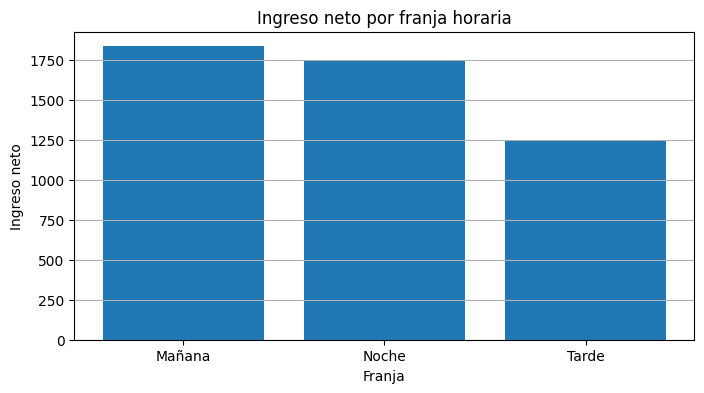

In [30]:
plt.figure(figsize=(8, 4))
plt.bar(ingresos_por_franja["franja"], ingresos_por_franja["ingreso_neto"])
plt.title("Ingreso neto por franja horaria")
plt.ylabel("Ingreso neto")
plt.xlabel("Franja")
plt.grid(axis="y")
plt.show()

## 8.4 Ejercicio 4 — Top productos por franja horaria

Para cada franja, obtenemos el top 3 de productos por ingreso neto.


In [31]:
top_por_franja = (
    df_f.groupby(["franja", "producto_id", "producto"], as_index=False)
        .agg(unidades=("cantidad", "sum"), ingreso_neto=("total_neto", "sum"))
)

top3_por_franja = (
    top_por_franja
        .sort_values(["franja", "ingreso_neto"], ascending=[True, False])
        .groupby("franja", as_index=False)
        .head(3)
        .reset_index(drop=True)
)
top3_por_franja

,franja,producto_id,producto,unidades,ingreso_neto
0,Mañana,P008,Jugo,130,338.73
1,Mañana,P006,Queso,79,327.49
2,Mañana,P004,Huevos,90,314.10
3,Noche,P006,Queso,96,385.49
4,Noche,P004,Huevos,101,362.60
5,Noche,P001,Café,110,244.49
6,Tarde,P006,Queso,83,341.61
7,Tarde,P008,Jugo,80,206.45
8,Tarde,P004,Huevos,45,162.52


## 8.5 Ejercicio 5 — Datos erróneos + etapa de limpieza

Inyectamos registros con problemas típicos:

- `cantidad = 0` o negativa
- `precio_unitario` negativo
- `total` nulo

La etapa de limpieza descarta filas inválidas, recalcula `total` cuando
hace falta, y reporta cuántas filas quedaron descartadas.


In [32]:
def inyectar_errores(df: pd.DataFrame, n_errores: int = 50, seed: int = 11) -> pd.DataFrame:
    rng = random.Random(seed)
    df_mal = df.copy()
    idxs = rng.sample(range(len(df_mal)), k=min(n_errores, len(df_mal)))
    tercio = len(idxs) // 3
    for i in idxs[:tercio]:
        df_mal.at[i, "cantidad"] = 0
    for i in idxs[tercio:2 * tercio]:
        df_mal.at[i, "precio_unitario"] = -abs(df_mal.at[i, "precio_unitario"])
    for i in idxs[2 * tercio:]:
        df_mal.at[i, "total"] = None
    return df_mal


def limpiar_ventas(df: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    total_inicial = len(df)
    df_limpio = df.copy()

    mask_cant = df_limpio["cantidad"] > 0
    mask_precio = df_limpio["precio_unitario"] > 0
    df_limpio = df_limpio[mask_cant & mask_precio].copy()

    df_limpio["total"] = (df_limpio["cantidad"] * df_limpio["precio_unitario"]).round(2)

    descartadas = total_inicial - len(df_limpio)
    stats = {
        "filas_iniciales": total_inicial,
        "filas_descartadas": descartadas,
        "filas_validas": len(df_limpio),
        "porcentaje_descartado": round(100 * descartadas / total_inicial, 2),
    }
    return df_limpio, stats


df_sucio = inyectar_errores(df_ventas, n_errores=60, seed=11)
df_limpio, stats = limpiar_ventas(df_sucio)

print("=== ESTADÍSTICAS DE LIMPIEZA ===")
for k, v in stats.items():
    print(f"{k:>22}: {v}")

ruta_limpio = "local/data/ventas_limpias.csv"
df_limpio.to_csv(ruta_limpio, index=False)

reporte_limpio = job_batch_reporte_diario(ruta_limpio)
print()
print("=== REPORTE BATCH (datos limpios) ===")
print(f"Ventas totales:   {reporte_limpio['ventas_totales']}")
print(f"Ingresos totales: {reporte_limpio['ingresos_totales']:.2f}")
print(f"Ticket promedio:  {reporte_limpio['ticket_promedio']:.2f}")

=== ESTADÍSTICAS DE LIMPIEZA ===
       filas_iniciales: 1200
     filas_descartadas: 40
         filas_validas: 1160
 porcentaje_descartado: 3.33

=== REPORTE BATCH (datos limpios) ===
Ventas totales:   1160
Ingresos totales: 5154.80
Ticket promedio:  4.44
